# Customer Churn Prediction Project

This notebook builds a machine learning model to predict customer subscription churn
based on usage behavior, engagement patterns, and payment information.

# Goal:
Identify at-risk customers and generate business insights for retention strategies.

## 1. Importing Libraries
Required libraries for data manipulation, visualization, and modeling.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

## 2. Data Loading
Load the customer dataset and inspect its structure.


In [4]:
df = pd.read_csv("customer_subscription_churn_usage_patterns.csv")

## 3. Data Preprocessing
Handle missing values, select features, and prepare data for modeling.


In [5]:
df.head()
df.isnull().sum()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 2800 non-null   int64  
 1   signup_date             2800 non-null   object 
 2   plan_type               2800 non-null   object 
 3   monthly_fee             2800 non-null   int64  
 4   avg_weekly_usage_hours  2800 non-null   float64
 5   support_tickets         2800 non-null   int64  
 6   payment_failures        2800 non-null   int64  
 7   tenure_months           2800 non-null   int64  
 8   last_login_days_ago     2800 non-null   int64  
 9   churn                   2800 non-null   object 
dtypes: float64(1), int64(6), object(3)
memory usage: 218.9+ KB


,user_id,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,434.214286,12.891429,3.887857,2.491786,18.612857,30.005000
std,808.434702,205.678472,7.109691,2.606419,1.691647,10.374487,17.852757
min,1.000000,199.000000,0.500000,0.000000,0.000000,1.000000,0.000000
25%,700.750000,199.000000,6.700000,2.000000,1.000000,10.000000,14.000000
50%,1400.500000,399.000000,12.800000,4.000000,2.000000,18.000000,30.000000
75%,2100.250000,699.000000,19.200000,6.000000,4.000000,27.000000,46.000000
max,2800.000000,699.000000,25.000000,8.000000,5.000000,36.000000,60.000000


In [6]:
df["churn"] = df["churn"].map({"Yes": 1, "No": 0})

In [7]:
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["tenure_days"] = (pd.to_datetime("today") - df["signup_date"]).dt.days
df.drop(columns=["signup_date", "user_id"], inplace=True)

In [8]:
df.head()

,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn,tenure_days
0,Premium,699,1.1,4,1,8,14,1,1022
1,Premium,699,2.6,6,0,35,1,1,888
2,Premium,699,14.3,8,3,2,14,1,842
3,Basic,199,17.6,5,2,11,9,1,782
4,Basic,199,9.8,5,2,6,38,1,1082


In [9]:
X = df.drop(columns="churn", axis=1)
y = df["churn"]

In [10]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include="object").columns

In [11]:
correlation = X[num_cols].corr()
correlation

,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,tenure_days
monthly_fee,1.000000,-0.030243,0.015366,-0.017959,0.014545,-0.003025,-0.001736
avg_weekly_usage_hours,-0.030243,1.000000,0.030636,0.013552,-0.010306,-0.002434,0.033918
support_tickets,0.015366,0.030636,1.000000,-0.007259,-0.044547,-0.058878,0.001999
payment_failures,-0.017959,0.013552,-0.007259,1.000000,0.022843,0.021437,-0.001936
tenure_months,0.014545,-0.010306,-0.044547,0.022843,1.000000,0.017535,-0.013632
last_login_days_ago,-0.003025,-0.002434,-0.058878,0.021437,0.017535,1.000000,0.016192
tenure_days,-0.001736,0.033918,0.001999,-0.001936,-0.013632,0.016192,1.000000


## 4. Exploratory Data Analysis (EDA)
Understand customer behavior patterns related to churn.


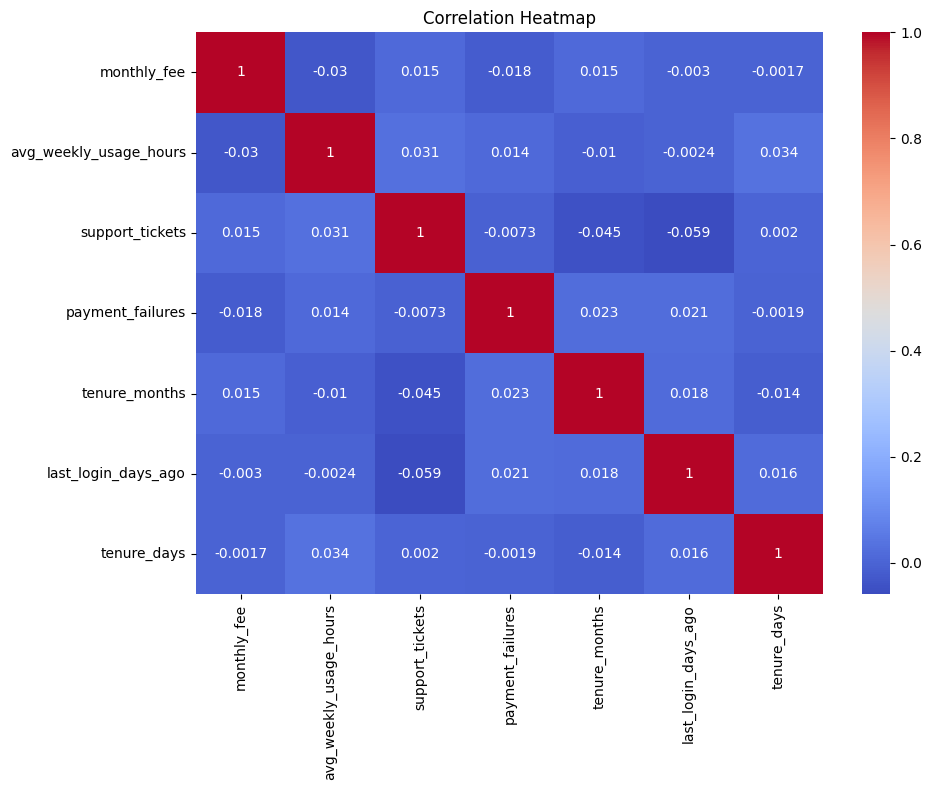

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

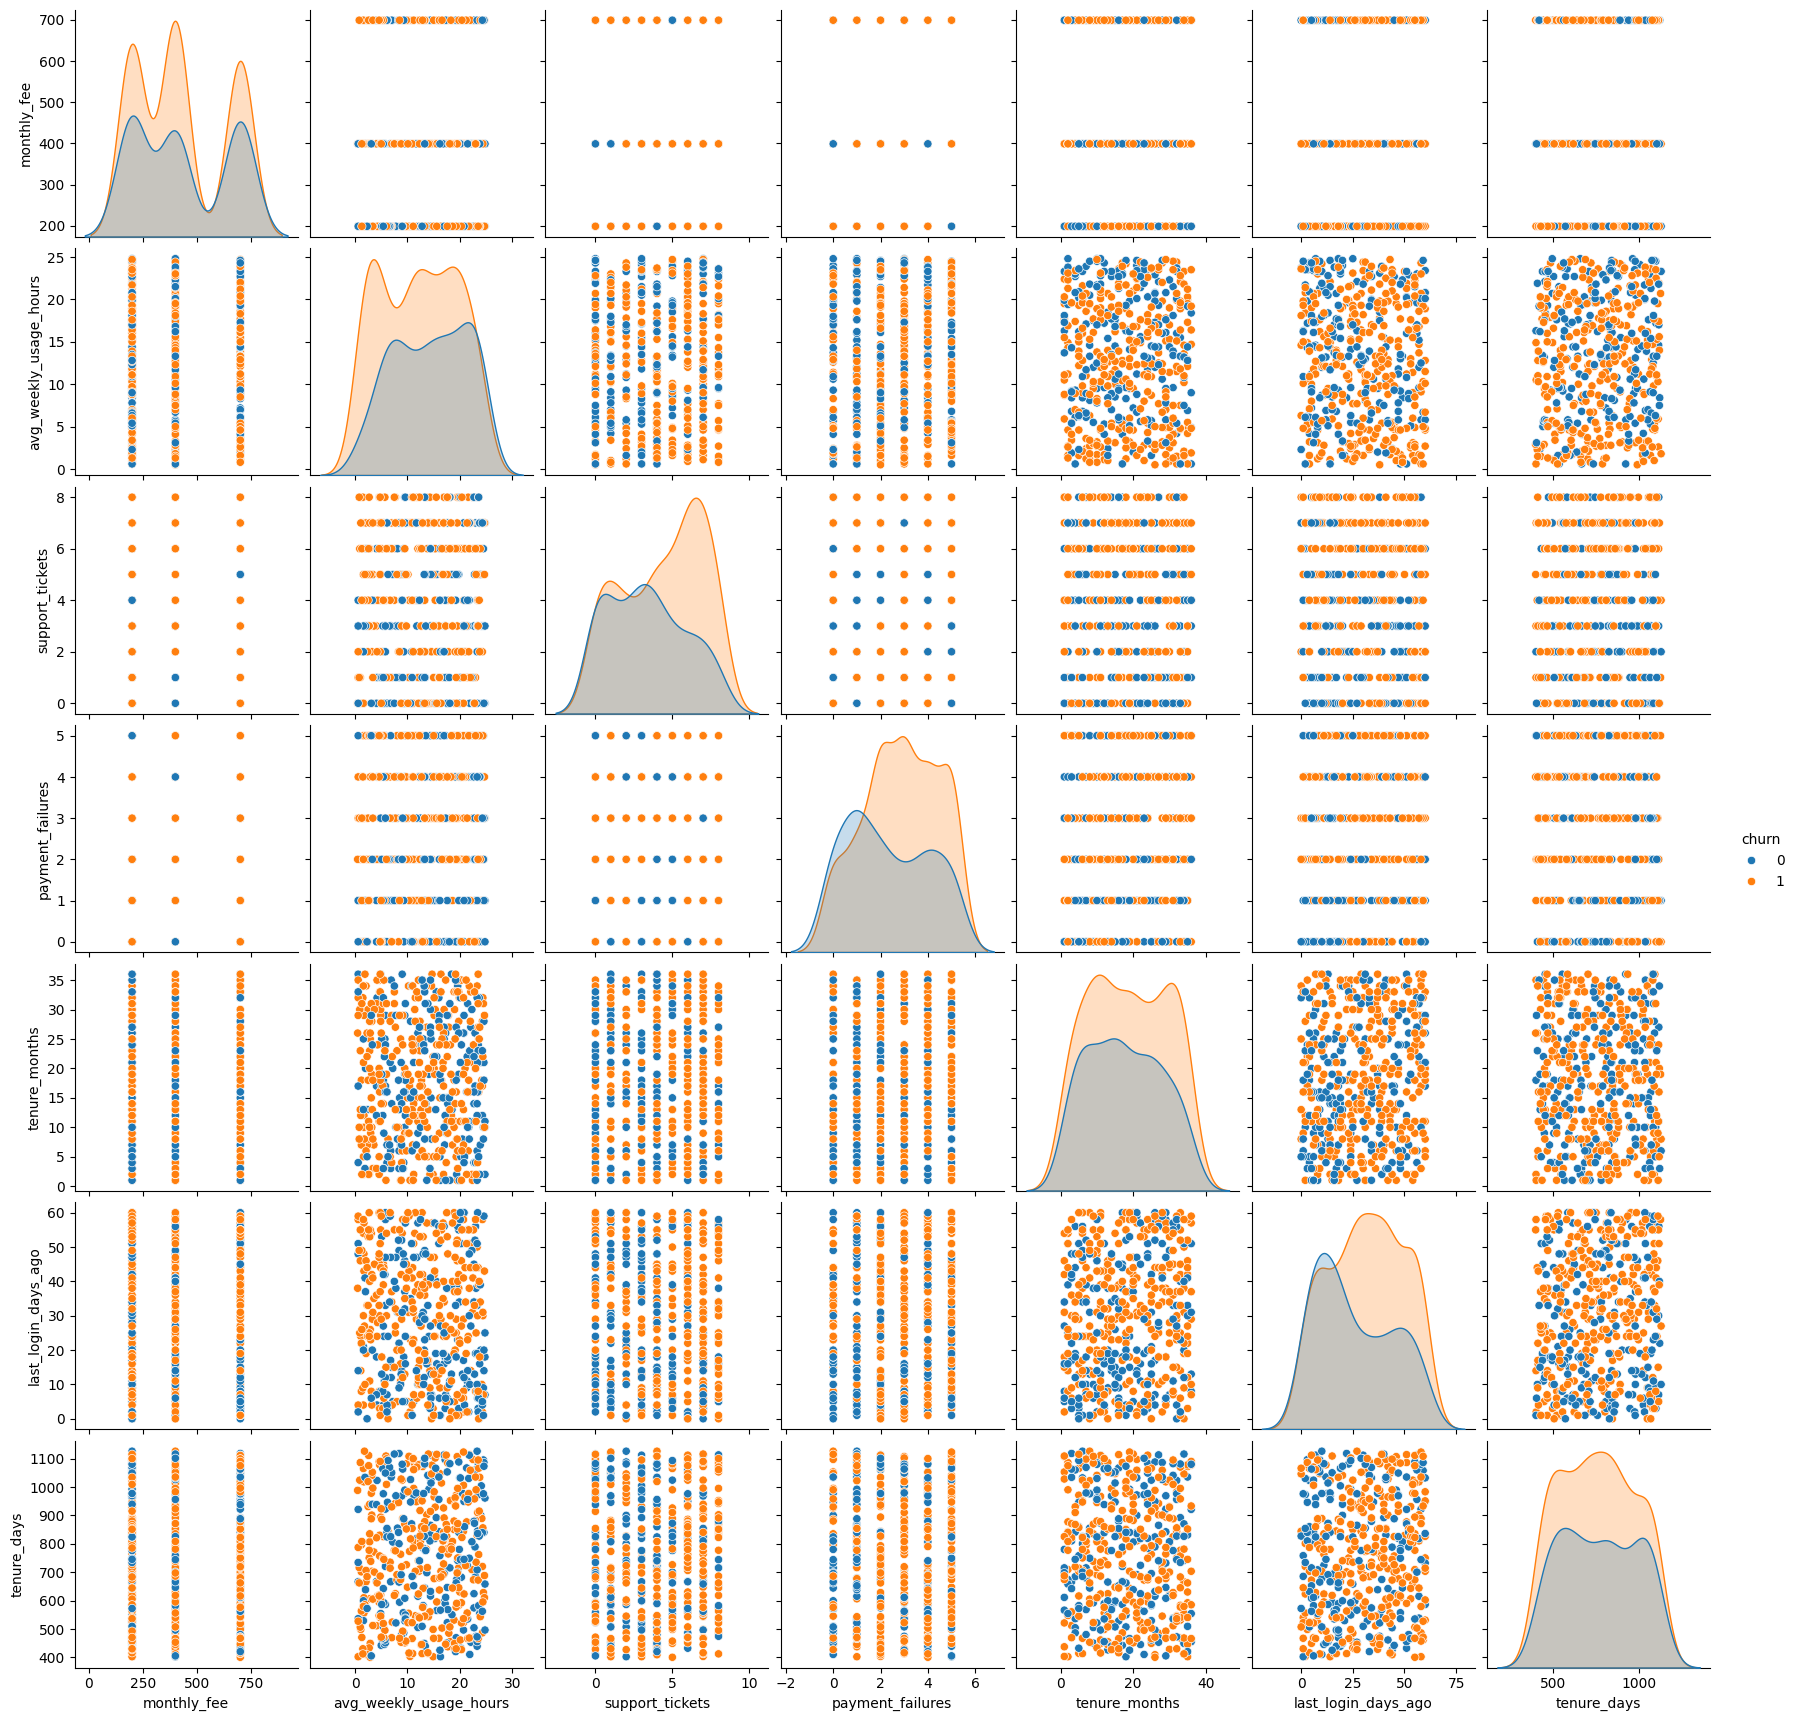

In [13]:
sns.pairplot(df.sample(500), hue="churn")
plt.show()

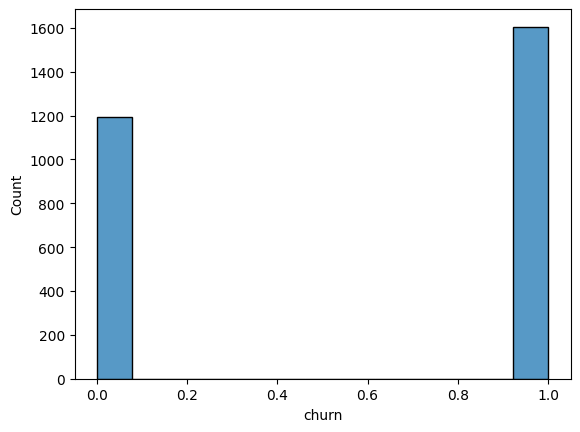

In [14]:
sns.histplot(df["churn"])
plt.show()

## 5. Train-Test Split
Split dataset to evaluate model generalization.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Numerical features: usage_hours, tenure, last_login_days

Categorical features: subscription_type

Different preprocessing is applied to each group.

In [16]:
# Standardizing numerical features so models like Logistic Regression
# and KNN perform better (they are sensitive to feature scale)

numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

## 6. Model Training
Train machine learning models for churn prediction.


In [17]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))
])

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])



## 7. Model Evaluation
Evaluate performance using accuracy, precision, recall, and confusion matrix.


In [18]:
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

for name, model in models.items():
  score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
  print(f"{name} ROC-AUC: , {score.mean():.3f}")

Logistic Regression ROC-AUC: , 0.695
Random Forest ROC-AUC: , 0.705
Gradient Boosting ROC-AUC: , 0.719


In [19]:
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

In [20]:
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score: ", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.53      0.58       239
           1       0.69      0.77      0.73       321

    accuracy                           0.67       560
   macro avg       0.66      0.65      0.65       560
weighted avg       0.66      0.67      0.66       560

Confusion Matrix:
 [[126 113]
 [ 73 248]]
ROC-AUC Score:  0.7015863084763878


In [21]:
rf_model.fit(X_train, y_train)

# Feature Importance from Random Forest
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["classifier"].feature_importances_

feat_imp = pd.DataFrame(importances, index=feature_names).sort_values(0, ascending=False)
feat_imp.head()

,0
num__avg_weekly_usage_hours,0.213221
num__last_login_days_ago,0.190668
num__tenure_days,0.181189
num__tenure_months,0.144766
num__payment_failures,0.113673


The most influential features were usage hours and last login days, indicating engagement is the strongest predictor of churn.

Customer engagement (usage hours & last login) is the strongest churn indicator. Tenure also plays a key role, meaning new customers are more unstable. Payment failures significantly increase churn probability.

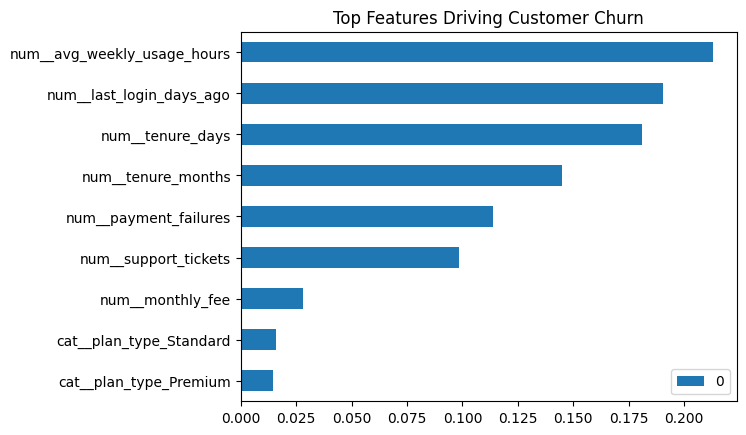

In [22]:
feat_imp.head(10).plot(kind="barh")
plt.title("Top Features Driving Customer Churn")
plt.gca().invert_yaxis()
plt.show()

In [23]:
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

In [24]:
print("Train ROC-AUC:", roc_auc_score(y_train, rf_model.predict_proba(X_train)[:,1]))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))

Train ROC-AUC: 1.0
Test ROC-AUC: 0.7258241113674578


There is overfitting

Training accuracy is high but test performance drops, indicating the model memorizes patterns instead of generalizing.

To solve this problem we can use:

1. Regularization

2. Cross-validation

3. Feature reduction

4. Hyperparameter tuning

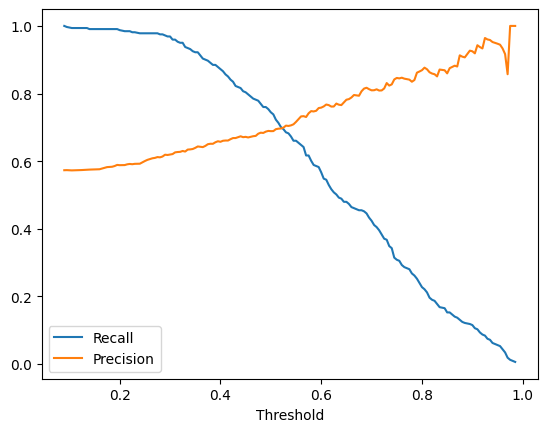

In [25]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [26]:
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score: ", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.55      0.58       239
           1       0.69      0.74      0.71       321

    accuracy                           0.66       560
   macro avg       0.65      0.65      0.65       560
weighted avg       0.66      0.66      0.66       560

Confusion Matrix:
 [[132 107]
 [ 84 237]]
ROC-AUC Score:  0.7258241113674578


In [27]:
gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)
y_proba = gb_model.predict_proba(X_test)[:, 1]

In [28]:
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score: ", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.61      0.63       239
           1       0.72      0.75      0.74       321

    accuracy                           0.69       560
   macro avg       0.69      0.68      0.68       560
weighted avg       0.69      0.69      0.69       560

Confusion Matrix:
 [[146  93]
 [ 79 242]]
ROC-AUC Score:  0.7506093666497217


Customers with low usage hours, long inactivity, short tenure, and payment failures are most likely to churn.
Retention strategies should target these users with engagement campaigns and billing support

# Business Interpretation:
Payment failures significantly increase churn risk.

Improving billing reliability may reduce customer loss.


## Conclusion

This project demonstrates how machine learning can predict customer churn
based on behavioral patterns. The model identifies at-risk customers and
provides actionable insights for improving retention strategies.
